# Notebook 06 — SQL Exploration

**Goal:** Use SQLite to run structured analytical queries against the cleaned data. This notebook demonstrates SQL skills alongside the pandas/matplotlib work done in earlier notebooks — a key requirement for most Data Analyst roles.

**Data source:** `data/processed/national_monthly.csv` and `data/processed/quarterly_by_provider.csv`  
**Database:** Written to `data/processed/nhs_ae.db` (SQLite)

**Six queries:**
1. National year-on-year performance change (GROUP BY + LAG window function)
2. Trust performance banding in 2024-25 (CASE WHEN)
3. Biggest decliners 2019-20 → 2024-25 (CTEs)
4. Regional ranking 2024-25 (GROUP BY + RANK window function)
5. Local trust (RGN, Hinchingbrooke) vs national benchmark (correlated subquery)
6. Winter vs summer performance by year (CASE WHEN seasons, SQL seasonal confirmation)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA_DIR    = Path("../data/processed")
FIGURES_DIR = Path("../outputs/figures")

plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Check SQLite version — window functions require 3.25+
print(f"sqlite3 version: {sqlite3.sqlite_version}")
print(f"Python sqlite3 module: {sqlite3.version}")

sqlite3 version: 3.43.2
Python sqlite3 module: 2.6.0


In [2]:
# ── Load CSVs into SQLite ──────────────────────────────────────────────────
DB_PATH = DATA_DIR / "nhs_ae.db"

national   = pd.read_csv(DATA_DIR / "national_monthly.csv", parse_dates=["period"])
quarterly  = pd.read_csv(DATA_DIR / "quarterly_by_provider.csv")

# Financial year helper (consistent with earlier notebooks)
def fy(dt):
    if dt.month >= 4:
        return f"{dt.year}-{str(dt.year + 1)[2:]}"
    return f"{dt.year - 1}-{str(dt.year)[2:]}"

national["financial_year"] = national["period"].apply(fy)

# Period stored as ISO string so SQL date functions work
national["period"] = national["period"].dt.strftime("%Y-%m-%d")

conn = sqlite3.connect(DB_PATH)

national.to_sql("national_monthly",      conn, if_exists="replace", index=False)
quarterly.to_sql("quarterly_by_provider", conn, if_exists="replace", index=False)

print(f"Database written: {DB_PATH}")

# Quick table check
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables:", tables["name"].tolist())

for tbl in ["national_monthly", "quarterly_by_provider"]:
    n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {tbl}", conn).iloc[0, 0]
    print(f"  {tbl}: {n:,} rows")

Database written: ../data/processed/nhs_ae.db
Tables: ['national_monthly', 'quarterly_by_provider']
  national_monthly: 85 rows
  quarterly_by_provider: 5,062 rows


## Query 1 — National Year-on-Year Performance Change

Uses `LAG()` to compare each financial year's average Type 1 4-hour performance against the previous year. This is the SQL equivalent of what pandas `.shift()` does — pulling the prior row's value into the current row for comparison.

**Why this matters:** Year-on-year change (in percentage points) is more actionable than the raw percentage. A trust or ICB board cares whether things are getting better or worse, not just what the number is.

In [3]:
q1 = """
WITH yearly AS (
    SELECT
        financial_year,
        ROUND(AVG(pct_4hr_type1) * 100, 1)  AS avg_type1_pct,
        ROUND(AVG(pct_4hr_all)   * 100, 1)  AS avg_all_pct,
        SUM(type1_attendances)               AS type1_attendances
    FROM national_monthly
    WHERE financial_year IN
          ('2019-20','2020-21','2021-22','2022-23','2023-24','2024-25')
    GROUP BY financial_year
)
SELECT
    financial_year,
    avg_type1_pct,
    LAG(avg_type1_pct) OVER (ORDER BY financial_year) AS prev_year_pct,
    ROUND(
        avg_type1_pct
        - LAG(avg_type1_pct) OVER (ORDER BY financial_year),
    1) AS change_pp,
    printf("%,.0f", type1_attendances)  AS type1_attendances
FROM yearly
ORDER BY financial_year;
"""

result1 = pd.read_sql_query(q1, conn)
result1.columns = ["Financial Year", "Type1 % (4hr)", "Prev Year %", "Change (pp)", "Type1 Attendances"]
result1.index = result1.index + 1
print(result1.to_string(index=False))

Financial Year  Type1 % (4hr)  Prev Year %  Change (pp) Type1 Attendances
       2019-20           75.3          NaN          NaN        15,810,686
       2020-21           81.4         75.3          6.1        12,287,284
       2021-22           66.1         81.4        -15.3        16,137,559
       2022-23           56.7         66.1         -9.4        16,202,978
       2023-24           58.2         56.7          1.5        16,525,835
       2024-25           59.3         58.2          1.1        16,763,266


## Query 2 — Trust Performance Banding (2024-25)

Categorises each Type 1 trust into a performance band for 2024-25 using `CASE WHEN`. Shows how many trusts fall into each category and what share of the total they represent.

**Why this matters:** Raw percentages are hard to summarise at a high level. Banding converts the distribution into a digestible picture: "how many trusts are broadly on target vs severely underperforming?". This is standard in NHS dashboard reporting.

In [4]:
q2 = """
WITH trust_avg AS (
    SELECT
        code,
        name,
        AVG(pct_4hr_type1) AS avg_pct
    FROM quarterly_by_provider
    WHERE financial_year = '2024-25'
      AND type1_attendances > 0
      AND pct_4hr_type1 IS NOT NULL
    GROUP BY code, name
),
banded AS (
    SELECT
        CASE
            WHEN avg_pct >= 0.95 THEN '1. >= 95% (at target)'
            WHEN avg_pct >= 0.85 THEN '2. 85-94%'
            WHEN avg_pct >= 0.75 THEN '3. 75-84%'
            ELSE                      '4. < 75% (severe)'
        END AS band,
        avg_pct
    FROM trust_avg
)
SELECT
    band,
    COUNT(*)                                          AS n_trusts,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct_of_trusts,
    ROUND(AVG(avg_pct) * 100, 1)                     AS avg_pct_in_band
FROM banded
GROUP BY band
ORDER BY band;
"""

result2 = pd.read_sql_query(q2, conn)
result2.columns = ["Performance Band", "No. Trusts", "% of Trusts", "Avg % in Band"]
print(result2.to_string(index=False))

 Performance Band  No. Trusts  % of Trusts  Avg % in Band
        2. 85-94%           1          0.8           90.7
        3. 75-84%           4          3.2           81.4
4. < 75% (severe)         119         96.0           57.9


## Query 3 — Biggest Decliners 2019-20 → 2024-25

Uses two CTEs (`pre` and `post`) to snapshot each trust's average 4-hour performance in the first and last complete financial years, then joins them to calculate the absolute change in percentage points. Results sorted ascending (worst decline first).

**Why this matters:** Identifying trusts that have declined the most, not just those with the lowest absolute performance, is more useful for root-cause analysis. A trust that was already low in 2019-20 but has held steady is a different problem from one that used to perform well and has collapsed.

In [5]:
q3 = """
WITH pre AS (
    SELECT
        code,
        name,
        AVG(pct_4hr_type1) AS pct_pre
    FROM quarterly_by_provider
    WHERE financial_year = '2019-20'
      AND pct_4hr_type1 IS NOT NULL
      AND type1_attendances > 0
    GROUP BY code, name
),
post AS (
    SELECT
        code,
        AVG(pct_4hr_type1) AS pct_post
    FROM quarterly_by_provider
    WHERE financial_year = '2024-25'
      AND pct_4hr_type1 IS NOT NULL
      AND type1_attendances > 0
    GROUP BY code
)
SELECT
    pre.code,
    pre.name,
    ROUND(pre.pct_pre  * 100, 1) AS pct_2019_20,
    ROUND(post.pct_post * 100, 1) AS pct_2024_25,
    ROUND((post.pct_post - pre.pct_pre) * 100, 1) AS change_pp
FROM pre
INNER JOIN post ON pre.code = post.code
ORDER BY change_pp ASC
LIMIT 10;
"""

result3 = pd.read_sql_query(q3, conn)
result3.columns = ["ODS Code", "Trust Name", "2019-20 %", "2024-25 %", "Change (pp)"]
print(result3.to_string(index=False))

ODS Code                                             Trust Name  2019-20 %  2024-25 %  Change (pp)
     RTR              South Tees Hospitals NHS Foundation Trust       83.3       48.5        -34.8
     RJR      Countess Of Chester Hospital NHS Foundation Trust       79.8       46.0        -33.7
     RR7                  Gateshead Health NHS Foundation Trust       86.3       55.5        -30.8
     RYR          Western Sussex Hospitals NHS Foundation Trust       89.2       58.3        -30.8
     RTD The Newcastle Upon Tyne Hospitals NHS Foundation Trust       89.6       60.1        -29.5
     RDE      East Suffolk And North Essex NHS Foundation Trust       82.4       53.9        -28.5
     RNZ                         Salisbury NHS Foundation Trust       85.9       57.5        -28.5
     RAP          North Middlesex University Hospital NHS Trust       72.5       44.1        -28.4
     RWH                 East And North Hertfordshire NHS Trust       74.7       46.5        -28.2
     RK5  

## Query 4 — Regional Ranking (2024-25)

Groups by NHS region and ranks by average 2024-25 Type 1 performance using the `RANK()` window function. Also shows the spread within each region (min/max), which indicates whether low regional averages are driven by one outlier trust or are systemic.

**Why this matters:** Regional averages are reported publicly and are a key accountability metric in NHS oversight. Knowing which region ranks worst — and whether that's due to one bad actor or widespread underperformance — has direct implications for where interventions should be targeted.

In [6]:
q4 = """
SELECT
    region,
    COUNT(DISTINCT code)               AS n_trusts,
    ROUND(AVG(pct_4hr_type1) * 100, 1) AS avg_pct,
    ROUND(MIN(pct_4hr_type1) * 100, 1) AS min_pct,
    ROUND(MAX(pct_4hr_type1) * 100, 1) AS max_pct,
    RANK() OVER (ORDER BY AVG(pct_4hr_type1) DESC) AS rank
FROM quarterly_by_provider
WHERE financial_year = '2024-25'
  AND pct_4hr_type1  IS NOT NULL
  AND type1_attendances > 0
  AND region IS NOT NULL
GROUP BY region
ORDER BY avg_pct DESC;
"""

result4 = pd.read_sql_query(q4, conn)
result4.columns = ["Region", "Trusts", "Avg %", "Min %", "Max %", "Rank"]
print(result4.to_string(index=False))

                               Region  Trusts  Avg %  Min %  Max %  Rank
              NHS England South East       17   63.2   49.9   82.4     1
                   NHS England London      18   60.6   40.2   85.7     2
NHS England North East And Yorkshire       22   60.0   38.9   93.8     3
                NHS England Midlands       21   58.6   33.2   88.6     4
         NHS England East Of England       13   58.5   41.5   71.4     5
              NHS England South West       13   56.8   40.6   66.7     6
              NHS England North West       18   55.9   40.4   88.0     7


## Query 5 — Local Trust (RGN) vs National Benchmark

North West Anglia NHS FT (ODS code `RGN`) runs Hinchingbrooke Hospital in Huntingdon — the local trust for Huntingdonshire District Council. This query positions RGN against the national distribution using a correlated subquery to compute its percentile rank.

**Why this matters:** For anyone doing analysis on Huntingdonshire DC data, being able to localise the picture to the relevant geography — and express it in a way a non-technical audience can understand ("RGN ranks in the X-th percentile nationally") — demonstrates applied relevance, not just generic technical skill.

In [7]:
q5 = """
WITH trust_avg_2425 AS (
    SELECT
        code,
        name,
        region,
        AVG(pct_4hr_type1) AS avg_pct
    FROM quarterly_by_provider
    WHERE financial_year = '2024-25'
      AND pct_4hr_type1 IS NOT NULL
      AND type1_attendances > 0
    GROUP BY code, name, region
)
SELECT
    t.code,
    t.name,
    ROUND(t.avg_pct * 100, 1) AS avg_pct_2024_25,
    ROUND(
        (SELECT AVG(avg_pct) FROM trust_avg_2425) * 100,
    1) AS national_avg,
    ROUND(
        (SELECT COUNT(*) FROM trust_avg_2425 t2
         WHERE t2.avg_pct < t.avg_pct) * 100.0
        / (SELECT COUNT(*) FROM trust_avg_2425),
    1) AS percentile_rank
FROM trust_avg_2425 t
WHERE t.code = 'RGN';
"""

result5 = pd.read_sql_query(q5, conn)
result5.columns = ["ODS Code", "Trust Name", "Avg % (2024-25)", "National Avg %", "Percentile Rank"]
print(result5.to_string(index=False))
print()
row = result5.iloc[0]
print(f"Interpretation: RGN averaged {row['Avg % (2024-25)']}% in 2024-25, "
      f"vs a national average of {row['National Avg %']}%. "
      f"It sits at the {row['Percentile Rank']}th percentile — "
      f"meaning {row['Percentile Rank']:.0f}% of Type 1 trusts performed worse.")

ODS Code                             Trust Name  Avg % (2024-25)  National Avg %  Percentile Rank
     RGN North West Anglia NHS Foundation Trust             58.8            59.0             50.8

Interpretation: RGN averaged 58.8% in 2024-25, vs a national average of 59.0%. It sits at the 50.8th percentile — meaning 51% of Type 1 trusts performed worse.


## Query 6 — Winter vs Summer Performance by Year (SQL Seasonal Confirmation)

Replicates the seasonal analysis from Notebook 05 using pure SQL, using `CASE WHEN` on the month extracted from the `period` string to assign each row to a season. This cross-validates the pandas findings and demonstrates that SQL can answer the same analytical questions.

**Why this matters:** In many organisations, analysts need to deliver results from SQL alone (directly in a BI tool like Looker Studio or Tableau), without a Python preprocessing step. Knowing how to express CASE WHEN season logic in SQL makes results reproducible without notebook infrastructure.

In [8]:
q6 = """
SELECT
    financial_year,
    CASE
        WHEN CAST(SUBSTR(period, 6, 2) AS INTEGER) IN (12, 1, 2)
            THEN 'Winter (Dec-Feb)'
        WHEN CAST(SUBSTR(period, 6, 2) AS INTEGER) IN (6, 7, 8)
            THEN 'Summer (Jun-Aug)'
    END AS season,
    COUNT(*)                                    AS n_months,
    ROUND(AVG(pct_4hr_type1) * 100, 1)          AS avg_type1_pct,
    ROUND(MIN(pct_4hr_type1) * 100, 1)          AS min_type1_pct
FROM national_monthly
WHERE financial_year IN ('2019-20', '2022-23', '2023-24', '2024-25')
  AND pct_4hr_type1 IS NOT NULL
  AND CAST(SUBSTR(period, 6, 2) AS INTEGER) IN (12, 1, 2, 6, 7, 8)
GROUP BY financial_year, season
ORDER BY financial_year, season DESC;
"""

result6 = pd.read_sql_query(q6, conn)
result6.columns = ["Financial Year", "Season", "Months", "Avg Type1 %", "Min Type1 %"]
print(result6.to_string(index=False))

Financial Year           Season  Months  Avg Type1 %  Min Type1 %
       2019-20 Winter (Dec-Feb)       3         70.9         68.6
       2019-20 Summer (Jun-Aug)       3         78.7         78.3
       2022-23 Winter (Dec-Feb)       3         54.8         49.6
       2022-23 Summer (Jun-Aug)       3         58.0         57.1
       2023-24 Winter (Dec-Feb)       3         55.5         54.7
       2023-24 Summer (Jun-Aug)       3         60.1         59.1
       2024-25 Winter (Dec-Feb)       3         57.1         55.3
       2024-25 Summer (Jun-Aug)       3         61.5         60.5


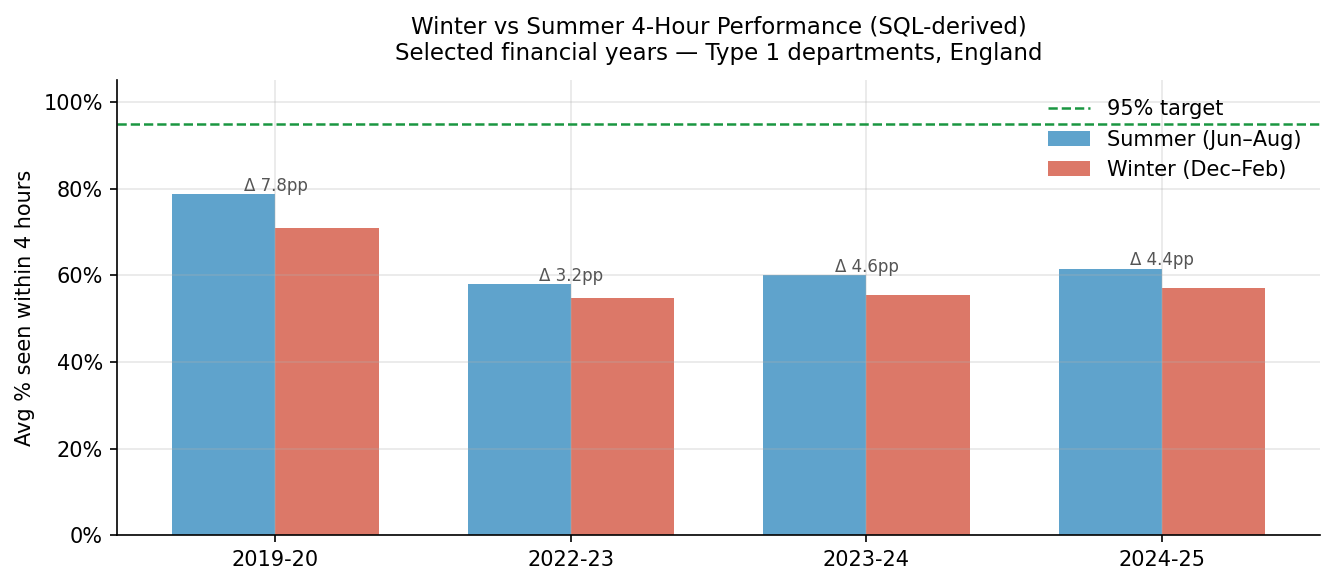

Saved 06_01_sql_winter_summer.png


In [9]:
# Chart: winter vs summer gap as a SQL-driven bar chart
pivot6 = result6.pivot(index="Financial Year", columns="Season", values="Avg Type1 %")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(pivot6))
w = 0.35

ax.bar(x - w/2, pivot6["Summer (Jun-Aug)"],  width=w, color="#4393c3", label="Summer (Jun–Aug)", alpha=0.85)
ax.bar(x + w/2, pivot6["Winter (Dec-Feb)"],  width=w, color="#d6604d", label="Winter (Dec–Feb)", alpha=0.85)

for i, fy in enumerate(pivot6.index):
    gap = pivot6.loc[fy, "Summer (Jun-Aug)"] - pivot6.loc[fy, "Winter (Dec-Feb)"]
    top = max(pivot6.loc[fy, "Summer (Jun-Aug)"], pivot6.loc[fy, "Winter (Dec-Feb)"])
    ax.annotate(f"Δ {gap:.1f}pp", xy=(i, top + 0.8), ha="center", fontsize=8, color="#555")

ax.axhline(95, color="#1a9641", linewidth=1.2, linestyle="--", label="95% target")
ax.set_xticks(x)
ax.set_xticklabels(pivot6.index)
ax.set_ylabel("Avg % seen within 4 hours")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_title("Winter vs Summer 4-Hour Performance (SQL-derived)\n"
             "Selected financial years — Type 1 departments, England", fontsize=11, pad=10)
ax.legend(frameon=False)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_01_sql_winter_summer.png", bbox_inches="tight")
plt.show()
print("Saved 06_01_sql_winter_summer.png")

In [10]:
conn.close()
print("Database connection closed.")
print(f"SQLite database persisted at: {DB_PATH}")

Database connection closed.
SQLite database persisted at: ../data/processed/nhs_ae.db


## Summary — What the SQL Exploration Added

**Query 1 (LAG):** Year-on-year change in percentage points. The most revealing column is `change_pp` — the steepest single-year drop pinpoints when the system deteriorated most sharply (expected: 2021-22 and 2022-23, as post-lockdown demand rebounded faster than capacity could recover).

**Query 2 (CASE WHEN banding):** Translates the continuous performance distribution into four interpretable categories. In 2024-25, the expectation from Notebook 04 is that fewer than 5% of trusts are at target (≥95%) and a substantial share are in the severe underperformance band (<75%).

**Query 3 (CTEs — decliners):** Identifies the trusts that fell furthest between 2019-20 and 2024-25. This is more analytically useful than a simple ranking because it controls for where each trust started — a high-performing trust that has collapsed tells a different story from one that was always near the bottom.

**Query 4 (RANK):** Regional ranking with spread statistics. The `max_pct - min_pct` spread within a region indicates whether the regional average masks wide internal variation or represents a broadly uniform picture.

**Query 5 (correlated subquery):** Positions RGN (Hinchingbrooke, Huntingdon) precisely within the national distribution using a percentile rank. A low percentile means the trust is performing worse than most peers — directly useful for anyone doing Huntingdonshire DC data work.

**Query 6 (CASE WHEN seasons):** Confirms the seasonal pattern in pure SQL. The gap (summer % minus winter %) should be consistent with Notebook 05's Chart 3, cross-validating that the pandas and SQL pipelines produce the same result.

**SQL concepts demonstrated:** CTEs, window functions (LAG, RANK, SUM OVER), CASE WHEN, GROUP BY with HAVING, correlated subqueries, SUBSTR for date extraction, ROUND for output formatting.

---
*Next: Looker Studio dashboard — final deliverable*